<a href="https://www.kaggle.com/code/trishyagupta/sfc-mago?scriptVersionId=346699342" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
from pycocotools.coco import COCO

# Adjust this path once you see the real one in the Kaggle sidebar
DATA_DIR = "/kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026"
train_img_dir = os.path.join(DATA_DIR, "train", "train_images")
train_json = os.path.join(DATA_DIR, "train", "MAGFiLO_1.0_Annotations_kaggle2026_train.json")

coco = COCO(train_json)
img_ids = coco.getImgIds()
print(f"Total annotated images: {len(img_ids)}")

img_info = coco.loadImgs([img_ids[0]])[0]
ann_ids = coco.getAnnIds(imgIds=img_info['id'])
anns = coco.loadAnns(ann_ids)
print(f"{img_info['file_name']} — {len(anns)} filaments annotated")

loading annotations into memory...
Done (t=0.64s)
creating index...
index created!
Total annotated images: 1154
20140609195854Bh.jpeg — 0 filaments annotated


Image shape: (2048, 2048), dtype: uint8, min: 0, max: 255


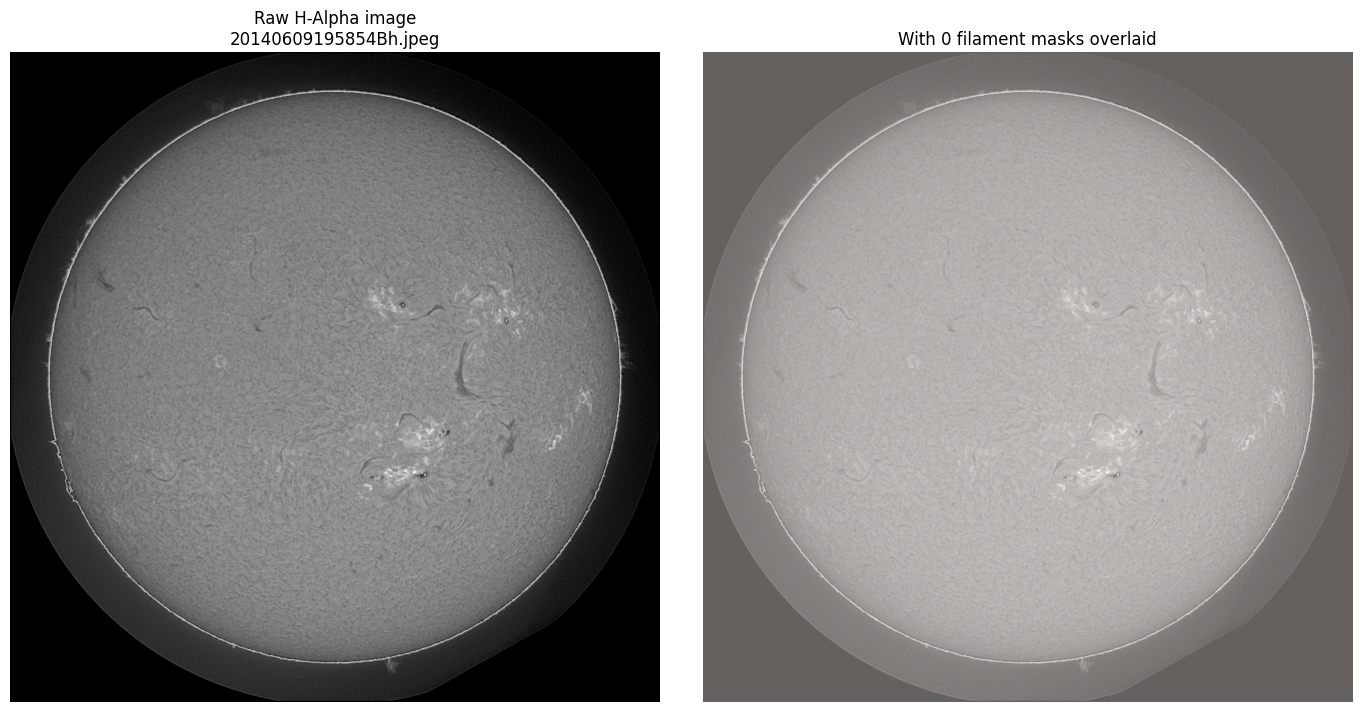

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_path = os.path.join(train_img_dir, img_info['file_name'])
image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

print(f"Image shape: {image.shape}, dtype: {image.dtype}, min: {image.min()}, max: {image.max()}")

mask = np.zeros(image.shape, dtype=np.uint8)
for ann in anns:
    m = coco.annToMask(ann)
    mask = np.maximum(mask, m)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(image, cmap='gray')
axes[0].set_title(f"Raw H-Alpha image\n{img_info['file_name']}")
axes[0].axis('off')

axes[1].imshow(image, cmap='gray')
axes[1].imshow(mask, cmap='Reds', alpha=0.4)
axes[1].set_title(f"With {len(anns)} filament masks overlaid")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Solar disk masking

# print(f"Image shape: {image.shape}, dtype: {image.dtype}, min: {image.min()}, max: {image.max()}")
def get_disk_mask(image, manual_threshold = 100):
  ret,thresh = cv2.threshold(image,manual_threshold,255,cv2.THRESH_BINARY)

## find contours in the threshold image
  contours,hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  contour_image=image.copy()

## largest contour
  largest_contour= max(contours,key = cv2.contourArea)

# Build a clean filled mask from that contour
  disk_mask = np.zeros(image.shape, dtype=np.uint8)
  cv2.drawContours(disk_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

# Apply the mask — zero out everything outside the disk
  image_disk_only = cv2.bitwise_and(image, image, mask=disk_mask)
  return  image_disk_only, disk_mask,


In [5]:
def run_disk_masking_pipeline(coco, img_ids, train_img_dir, output_dir,
                                manual_threshold=100, log_every=100):
    os.makedirs(output_dir, exist_ok=True)

    failed_images = []
    area_report = []

    total = len(img_ids)
    for i, img_id in enumerate(img_ids):
        info = coco.loadImgs([img_id])[0]
        img_path = os.path.join(train_img_dir, info['file_name'])
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            failed_images.append((info['file_name'], "failed to load image file"))
            continue

        try:
            image_disk_only, disk_mask = get_disk_mask(image)
            area_frac = (disk_mask > 0).sum() / disk_mask.size
            area_report.append((info['file_name'], area_frac))

            out_path = os.path.join(output_dir, info['file_name'])
            cv2.imwrite(out_path, image_disk_only)

        except Exception as e:
            failed_images.append((info['file_name'], str(e)))

        if (i + 1) % log_every == 0 or (i + 1) == total:
            print(f"Processed {i + 1}/{total} images "
                  f"({len(failed_images)} failures so far)")

    print("\n=== Disk masking complete ===")
    print(f"Total images: {total}")
    print(f"Successfully processed: {len(area_report)}")
    print(f"Hard failures: {len(failed_images)}")

    if failed_images:
        print("\nFailed images (name, reason):")
        for name, reason in failed_images:
            print(f"  {name}: {reason}")
    ### This detect outliers means image whose disk is different from others....
    if area_report:
        areas = np.array([a for image, a in area_report])
        mean_area, std_area = areas.mean(), areas.std()
        print(f"\nDisk area fraction — mean: {mean_area:.1%}, std: {std_area:.1%}")

        outliers = [(name, a) for name, a in area_report if abs(a - mean_area) > 2 * std_area]
        print(f"Outlier images (>2 std from mean, {len(outliers)} total):")
        for name, a in outliers[:2]:
            print(f"  {name}: {a:.1%}")
        if len(outliers) > 20:
            print(f"  ... and {len(outliers) - 2} more")

    return failed_images, area_report


# --- Run it ---
OUTPUT_DIR = "/kaggle/working/disk_masked_images"
failed, report = run_disk_masking_pipeline(
    coco=coco,
    img_ids=img_ids,
    train_img_dir=train_img_dir,
    output_dir=OUTPUT_DIR,
    manual_threshold=100,
)

Processed 100/1154 images (0 failures so far)
Processed 200/1154 images (0 failures so far)
Processed 300/1154 images (0 failures so far)
Processed 400/1154 images (0 failures so far)
Processed 500/1154 images (0 failures so far)
Processed 600/1154 images (0 failures so far)
Processed 700/1154 images (0 failures so far)
Processed 800/1154 images (0 failures so far)
Processed 900/1154 images (0 failures so far)
Processed 1000/1154 images (0 failures so far)
Processed 1100/1154 images (0 failures so far)
Processed 1154/1154 images (0 failures so far)

=== Disk masking complete ===
Total images: 1154
Successfully processed: 1154
Hard failures: 0

Disk area fraction — mean: 61.7%, std: 1.5%
Outlier images (>2 std from mean, 35 total):
  20220618185332Bh.jpeg: 65.4%
  20220721185332Bh.jpeg: 66.5%
  ... and 33 more


In [6]:
##CLAHE (Contrast Limited Adaptive Histogram Equalization) --> enhance local contrast and reveal hidden details in dark or bright regions
# Apply CLAHE on top of your disk-masked image
def apply_clahe (image):
   clahe = cv2.createCLAHE(clipLimit= 2.0, tileGridSize=(2,2))
   clahe_image= clahe.apply(image)
   return clahe_image

In [7]:
CLAHE_OUTPUT_DIR = "/kaggle/working/clahe_images"
os.makedirs(CLAHE_OUTPUT_DIR, exist_ok=True)
failed_clahe = []
image_list = os.listdir(OUTPUT_DIR)
total = len(image_list)

for i, img in enumerate(image_list):
    img_path = os.path.join(OUTPUT_DIR, img)
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        failed_clahe.append((img, "failed to load"))
        continue

    try:
        image_clahe = apply_clahe(image)
        out_path = os.path.join(CLAHE_OUTPUT_DIR, img)
        success = cv2.imwrite(out_path, image_clahe)
        if not success:
            failed_clahe.append((img, "cv2.imwrite returned False"))
    except Exception as e:
        failed_clahe.append((img, str(e)))

    if (i + 1) % 100 == 0 or (i + 1) == total:
        print(f"Processed {i + 1}/{total} images")


Processed 100/707 images
Processed 200/707 images
Processed 300/707 images
Processed 400/707 images
Processed 500/707 images
Processed 600/707 images
Processed 700/707 images
Processed 707/707 images


In [8]:
input_files = set(os.listdir(train_img_dir))
disk_masked_files = set(os.listdir(OUTPUT_DIR))
clahe_files = set(os.listdir(CLAHE_OUTPUT_DIR))

print(f"Input images: {len(input_files)}")
print(f"Disk-masked output: {len(disk_masked_files)}")
print(f"CLAHE output: {len(clahe_files)}")

Input images: 707
Disk-masked output: 707
CLAHE output: 707
